In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow import keras
from tensorflow.keras import layers

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving airline-passengers.csv to airline-passengers.csv


In [4]:
df = pd.read_csv('airline-passengers.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (144, 2)

First 5 rows:
     month  total_passengers
0  1949-01               112
1  1949-02               118
2  1949-03               132
3  1949-04               129
4  1949-05               121


In [5]:
print("Column Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
Index(['month', 'total_passengers'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             144 non-null    object
 1   total_passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB

Missing Values:
month               0
total_passengers    0
dtype: int64


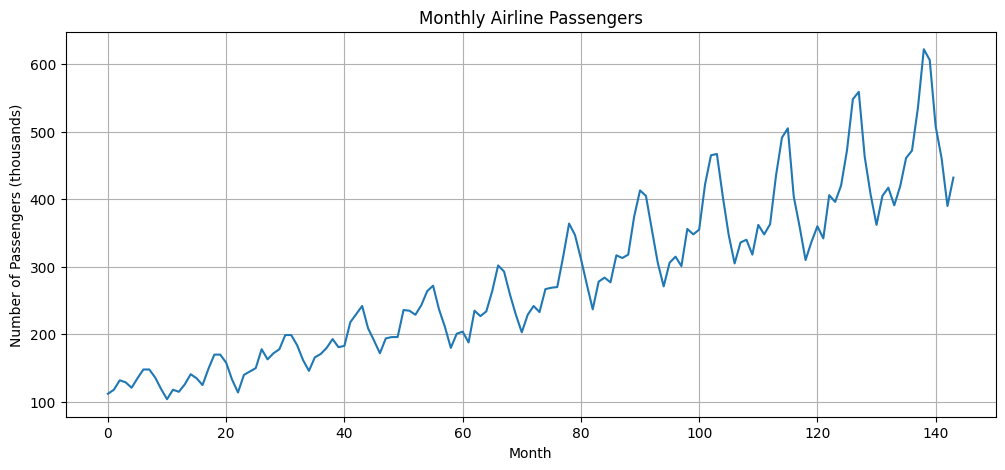

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(df['total_passengers'])

plt.title('Monthly Airline Passengers')
plt.xlabel('Month')
plt.ylabel('Number of Passengers (thousands)')
plt.grid(True)

plt.show()

In [9]:
data = df['total_passengers'].values.reshape(-1, 1)

print("Data Shape:", data.shape)
print("\nFirst 10 passenger values:")
print(data[:10])

Data Shape: (144, 1)

First 10 passenger values:
[[112]
 [118]
 [132]
 [129]
 [121]
 [135]
 [148]
 [148]
 [136]
 [119]]


In [10]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

print("Original data:")
print(data[:5])

print("\nScaled data:")
print(scaled_data[:5])

Original data:
[[112]
 [118]
 [132]
 [129]
 [121]]

Scaled data:
[[0.01544402]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]]


In [11]:
def create_dataset(dataset, lookback=12):
    X, y = [], []

    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback, 0])
        y.append(dataset[i + lookback, 0])

    return np.array(X), np.array(y)

In [12]:
LOOKBACK = 12

X, y = create_dataset(scaled_data, LOOKBACK)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (132, 12)
y Shape: (132,)


In [13]:
print("First input sequence:")
print(X[0])

print("\nFirst target:")
print(y[0])

First input sequence:
[0.01544402 0.02702703 0.05405405 0.04826255 0.03281853 0.05984556
 0.08494208 0.08494208 0.06177606 0.02895753 0.         0.02702703]

First target:
0.02123552123552122


In [14]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 105
Testing samples: 27


In [15]:
X_train = X_train.reshape(
    (X_train.shape[0], X_train.shape[1], 1)
)

X_test = X_test.reshape(
    (X_test.shape[0], X_test.shape[1], 1)
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (105, 12, 1)
Testing Set: (27, 12, 1)


In [16]:
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),

    layers.LSTM(
        50,
        activation='relu',
        return_sequences=True
    ),

    layers.LSTM(
        50,
        activation='relu'
    ),

    layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='mse'
)

print("Model compiled successfully!")

Model compiled successfully!


In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=8,
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0813 - val_loss: 0.1813
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0194 - val_loss: 0.0206
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0133 - val_loss: 0.0254
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0086 - val_loss: 0.0219
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0072 - val_loss: 0.0260
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0068 - val_loss: 0.0226
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0068 - val_loss: 0.0221
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0068 - val_loss: 0.0203
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0106 - val_loss: 0.0285
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0079 - val_loss: 0.0200
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0071 - val_loss: 0.0196
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

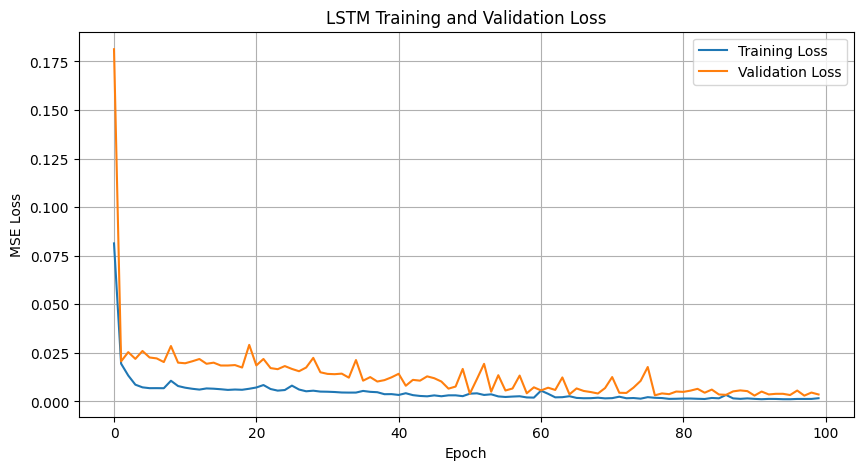

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training Predictions Shape:", train_pred.shape)
print("Testing Predictions Shape:", test_pred.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Training Predictions Shape: (105, 1)
Testing Predictions Shape: (27, 1)


In [21]:
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(
    y_train.reshape(-1, 1)
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("First 5 actual test values:")
print(y_test_actual[:5])

print("\nFirst 5 predicted test values:")
print(test_pred[:5])

First 5 actual test values:
[[359.]
 [310.]
 [337.]
 [360.]
 [342.]]

First 5 predicted test values:
[[402.2824 ]
 [361.49164]
 [342.77127]
 [329.80252]
 [328.6765 ]]


In [22]:
train_rmse = np.sqrt(
    mean_squared_error(
        y_train_actual,
        train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        test_pred
    )
)

print("Train RMSE:", round(train_rmse, 2))
print("Test RMSE:", round(test_rmse, 2))

Train RMSE: 17.53
Test RMSE: 30.97


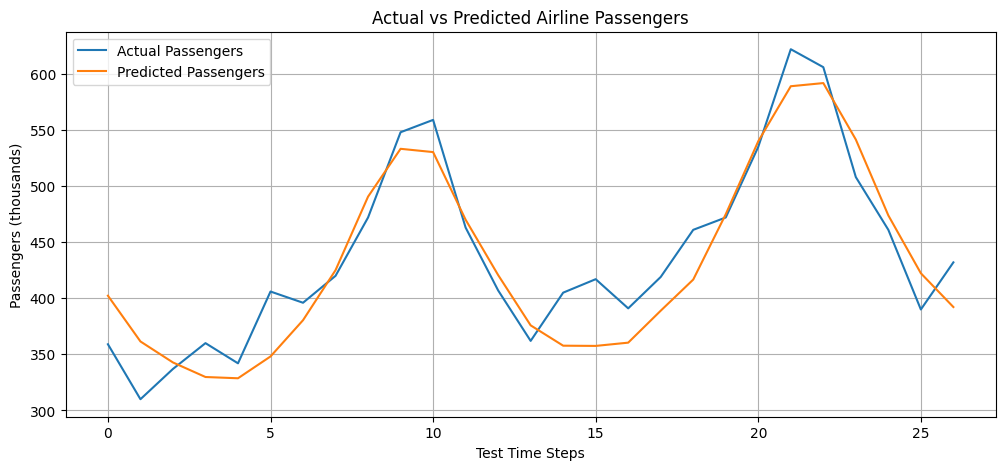

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual,
    label='Actual Passengers'
)

plt.plot(
    test_pred,
    label='Predicted Passengers'
)

plt.title('Actual vs Predicted Airline Passengers')
plt.xlabel('Test Time Steps')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.grid(True)

plt.show()

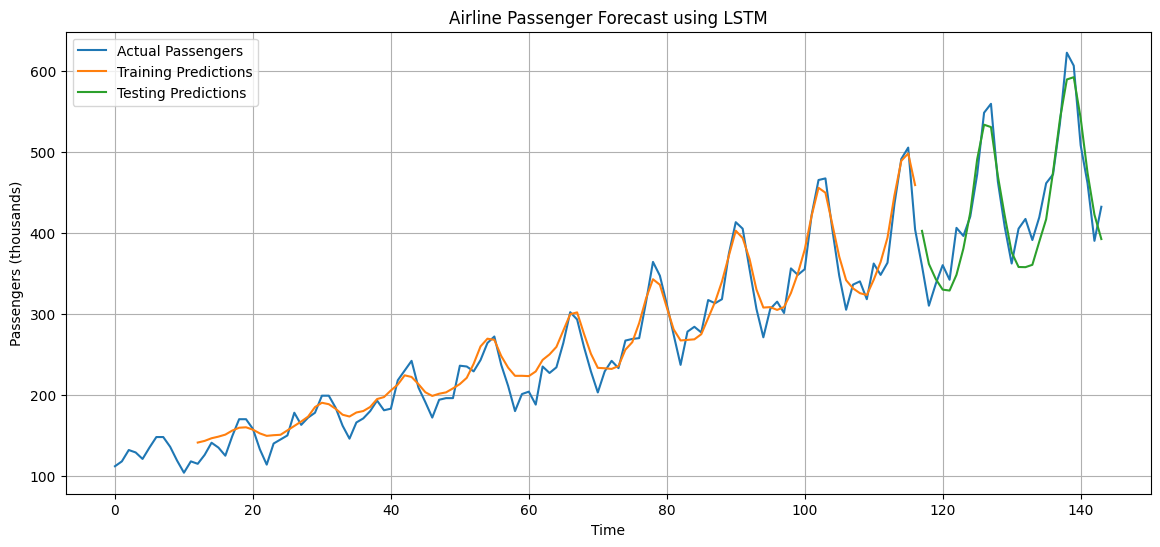

In [24]:
train_plot = np.full_like(scaled_data, np.nan, dtype=float)
test_plot = np.full_like(scaled_data, np.nan, dtype=float)

train_plot[LOOKBACK:LOOKBACK + len(train_pred)] = train_pred
test_plot[
    LOOKBACK + len(train_pred):
    LOOKBACK + len(train_pred) + len(test_pred)
] = test_pred

plt.figure(figsize=(14, 6))

plt.plot(
    data,
    label='Actual Passengers'
)

plt.plot(
    train_plot,
    label='Training Predictions'
)

plt.plot(
    test_plot,
    label='Testing Predictions'
)

plt.title('Airline Passenger Forecast using LSTM')
plt.xlabel('Time')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.grid(True)

plt.show()

In [25]:
results = pd.DataFrame({
    'Metric': ['Train RMSE', 'Test RMSE'],
    'Value': [
        round(train_rmse, 2),
        round(test_rmse, 2)
    ]
})

print(results)

       Metric  Value
0  Train RMSE  17.53
1   Test RMSE  30.97


In [26]:
model.save('lstm_forecast.h5')

print("Model saved successfully!")

Model saved successfully!
